# CS690R: Bio-PM IRB Embedding Extraction (Alt: 9-second grouped blocks)

**Alt vs standard pipeline:**

| | Standard | Alt |
|---|---|---|
| Window size | 3s (90 samples) | 9s (270 samples, 3 windows grouped) |
| pad_size | 57 | 171 |
| Expected MEs/block | ~18.6 | ~55+ |
| Expected fill rate | ~33% | ~96% |
| Blocks per visit | ~28,800 | ~9,600 |

Higher fill rate means the std-pool dims `[64:128]` of the transformer stream become
reliable variance estimates instead of collapsing toward zero.

**Run alt scripts first:**
```bash
conda activate biopm-690r
export BIOPM_ROOT=CS690TR
bash run_extraction_pipeline_alt.sh
```

**Embedding layout (1028-d, same as standard):**
```
[0:64]     mean-pool transformer tokens   (movement element structure)
[64:128]   std-pool transformer tokens    (movement variability) -- BETTER in alt pipeline
[128:1028] gravity flattened 300x3        (posture/orientation)  -- same as standard
```

In [1]:
# ============================================================
# PATHS -- alt pipeline configuration
# All paths use _alt suffix to avoid touching standard outputs
# ============================================================
import os
REPO_ROOT         = os.path.abspath(".")
BIOPM_ROOT        = os.path.join(REPO_ROOT, "CS690TR")
DATA_DIR          = "data"                                        # unchanged -- shared source
PREPROCESSED_DIR  = "preprocessed_alt"                           # written by irb_preprocess_alt.py
FEATURES_PATH     = "features/biopm_features_alt.npz"            # written by irb_extract.py
LEGACY_FEATURES_PATH = "features/biopm_features_legacy_schema_alt.npz"  # written by export_legacy_schema.py
RESULTS_DIR       = "results"
FIGURES_DIR       = "results/figures"
SPLITS_DIR        = "results/splits"
LR_RESULTS_PATH   = "results/lr_loso_results_alt.txt"

# Alt Bio-PM config -- pad_size scaled to 9-second blocks
GROUP_SIZE = 3          # consecutive windows grouped per block
ALT_PAD_SIZE = 171      # GROUP_SIZE * 57 = 171

# Debug settings (Section 2)
DEBUG_SUBJECT   = 549
DEBUG_N_WINDOWS = 20

In [2]:
%matplotlib inline
import os
import sys
import warnings
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pandas
import sklearn
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import umap
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

if not os.path.isdir(BIOPM_ROOT):
    raise RuntimeError(
        f"BIOPM_ROOT not found: {BIOPM_ROOT!r}\n"
        "Update BIOPM_ROOT in the config cell above."
    )
if BIOPM_ROOT not in sys.path:
    sys.path.insert(0, BIOPM_ROOT)

from src.data.preprocessing import bandpass_filter, lowpass_filter, detect_zero_crossings
from src.models.biopm import BioPMModel, masked_mean_std

CHECKPOINT = os.path.join(BIOPM_ROOT, "checkpoints", "checkpoint.pt")

print(f"torch      : {torch.__version__}")
print(f"numpy      : {np.__version__}")
print(f"scipy      : {scipy.__version__}")
print(f"pandas     : {pandas.__version__}")
print(f"sklearn    : {sklearn.__version__}")
print(f"checkpoint : {'OK' if os.path.isfile(CHECKPOINT) else 'NOT FOUND -- check BIOPM_ROOT'}")
print(f"pad_size   : {ALT_PAD_SIZE}  (alt, vs 57 in standard)")
print("All imports OK")

torch      : 2.11.0
numpy      : 2.4.3
scipy      : 1.17.1
pandas     : 3.0.2
sklearn    : 1.8.0
checkpoint : OK
pad_size   : 171  (alt, vs 57 in standard)
All imports OK


## 1. Inspect Dataset

Same source data as the standard pipeline -- this section is unchanged.
Run once to understand structure. Skip if already run in the standard notebook.

In [3]:
def _hr(label="", w=60):
    if label:
        pad = (w - len(label) - 2) // 2
        print("=" * pad + f" {label} " + "=" * (w - pad - len(label) - 2))
    else:
        print("=" * w)

# ---- clinical_scores ----
_hr("clinical_scores.npz")
raw  = np.load(f"{DATA_DIR}/clinical_scores.npz", allow_pickle=True)
clin = raw["clinical_scores"].item()
keys = list(clin.keys())

subjects = sorted(set(k[0] for k in keys))
weeks    = sorted(set(k[1] for k in keys))
arats    = np.array([clin[k].ARAT for k in keys])
fmas     = np.array([clin[k].FMA  for k in keys])
healthy  = {k[0] for k in keys if clin[k].ARAT == 57 and clin[k].FMA == 66}
stroke   = {k[0] for k in keys} - healthy

print(f"Total (subj, week) entries : {len(keys)}")
print(f"Unique subjects            : {len(subjects)}  {subjects[:10]}...")
print(f"Healthy subjects (max score): {len(healthy)}  {sorted(healthy)}")
print(f"Stroke  subjects            : {len(stroke)}")

# ---- windows ----
_hr("windows.npz")
print("Loading windows.npz (may take 1-2 min) ...", flush=True)
raw_wins = np.load(f"{DATA_DIR}/windows.npz", allow_pickle=True)
windows  = raw_wins["windows"]
w0       = windows[0]

print(f"Total windows   : {len(windows)}")
print(f"wnd.acc shape   : {w0.acc.shape}  (90 samples = 3s at 30 Hz)")

counts = Counter((w.subject, w.week) for w in windows)
vals   = list(counts.values())
print(f"Windows per (subj,week): min={min(vals)}  max={max(vals)}  median={np.median(vals):.0f}")
print(f"\nAlt grouping: {GROUP_SIZE} windows -> 1 block ({GROUP_SIZE*90} samples = {GROUP_SIZE*3}s)")
print(f"Blocks per (subj,week): ~{int(np.median(vals)) // GROUP_SIZE} (vs ~{int(np.median(vals))} windows)")
_hr()

=================== clinical_scores.npz ====================
Total (subj, week) entries : 223
Unique subjects            : 61  [500, 502, 503, 506, 507, 509, 510, 512, 515, 516]...
Healthy subjects (max score): 8  [509, 517, 526, 529, 532, 533, 539, 551]
Stroke  subjects            : 53
======================= windows.npz ========================
Loading windows.npz (may take 1-2 min) ...
Total windows   : 587046
wnd.acc shape   : (90, 3)  (90 samples = 3s at 30 Hz)
Windows per (subj,week): min=55  max=12617  median=2119

Alt grouping: 3 windows -> 1 block (270 samples = 9s)
Blocks per (subj,week): ~706 (vs ~2119 windows)


## 2. Debug Pipeline (Alt Config)

Same diagnostic as standard notebook, but uses `pad_size=171` and simulates
the grouped 9-second block to show the fill rate improvement.

In [4]:
# Helper functions (identical to standard notebook)
def hr(label="", w=64):
    if label:
        pad = (w - len(label) - 2) // 2
        print("=" * pad + f" {label} " + "=" * (w - pad - len(label) - 2))
    else:
        print("=" * w)

def check_array(name, arr, indent=4):
    sp = " " * indent
    if arr is None:
        print(f"{sp}{name}: None")
        return
    flat   = arr.flatten()
    n_nan  = int(np.isnan(flat).sum())
    n_inf  = int(np.isinf(flat).sum())
    finite = flat[np.isfinite(flat)]
    if len(finite) > 0:
        print(f"{sp}{name}: shape={arr.shape}  dtype={arr.dtype}")
        print(f"{sp}  range=[{finite.min():.4f}, {finite.max():.4f}]  mean={finite.mean():.4f}  std={finite.std():.4f}")
        print(f"{sp}  NaN={n_nan}/{len(flat)}  Inf={n_inf}")
        if n_nan == len(flat):
            print(f"{sp}  *** ALL NaN -- zero/garbage embeddings ***")
    else:
        print(f"{sp}{name}: ALL NaN or Inf -- {arr.shape}")

In [5]:
# Alt debug config -- pad_size=171 for 9-second blocks
DEBUG_CONFIG_STD = {
    "HighF1": 12, "LowF1": 0.5, "Order1": 6,
    "target_FS": 30, "WS": 3, "pad_size": 57,
    "normalize_size_target": 32, "normalize_size_assign": 32,
}
DEBUG_CONFIG_ALT = {
    "HighF1": 12, "LowF1": 0.5, "Order1": 6,
    "target_FS": 30, "WS": 9, "pad_size": ALT_PAD_SIZE,
    "normalize_size_target": 32, "normalize_size_assign": 32,
}

hr("Load data")
_clin     = np.load(f"{DATA_DIR}/clinical_scores.npz", allow_pickle=True)["clinical_scores"].item()
_wins_all = np.load(f"{DATA_DIR}/windows.npz", allow_pickle=True)["windows"]
dbg_windows = [w for w in _wins_all if w.subject == DEBUG_SUBJECT]
if not dbg_windows:
    raise RuntimeError(f"Subject {DEBUG_SUBJECT} not found.")
dbg_test = dbg_windows[:DEBUG_N_WINDOWS]
clin_key = (DEBUG_SUBJECT, dbg_test[0].week)
if clin_key in _clin:
    arat = _clin[clin_key].ARAT
    fma  = _clin[clin_key].FMA
    print(f"Subject {DEBUG_SUBJECT}: ARAT={arat:.0f}  FMA={fma:.0f}  "
          f"({'healthy' if arat==57 and fma==66 else 'stroke'})")

# --- Standard: ME count on individual 3s windows ---
hr("ME count: standard (individual 3s windows, pad_size=57)")
me_counts_std = []
for wnd in dbg_test:
    t_w = np.arange(wnd.acc.shape[0]) / DEBUG_CONFIG_STD["target_FS"]
    try:
        acc_f = bandpass_filter(wnd.acc, DEBUG_CONFIG_STD["LowF1"], DEBUG_CONFIG_STD["HighF1"],
                                DEBUG_CONFIG_STD["target_FS"], order=DEBUG_CONFIG_STD["Order1"])
        (_, _, me_list, _, _, _, _, _, _, _) = detect_zero_crossings(acc_f, t_w, DEBUG_CONFIG_STD)
        me_counts_std.append(len(me_list))
    except Exception:
        me_counts_std.append(0)

me_counts_std = np.array(me_counts_std)
fill_std = 100 * me_counts_std.mean() / 57
print(f"MEs per window : mean={me_counts_std.mean():.1f}  (min={me_counts_std.min()} max={me_counts_std.max()})")
print(f"Fill rate      : {fill_std:.1f}%  ({me_counts_std.mean():.1f} / 57 slots)")

# --- Alt: ME count on grouped 9s blocks ---
hr(f"ME count: alt (grouped {GROUP_SIZE}x3s = 9s blocks, pad_size={ALT_PAD_SIZE})")
me_counts_alt = []
for i in range(0, len(dbg_test) - GROUP_SIZE + 1, GROUP_SIZE):
    block = np.concatenate([dbg_test[j].acc for j in range(i, i + GROUP_SIZE)], axis=0)
    t_blk = np.arange(block.shape[0]) / DEBUG_CONFIG_ALT["target_FS"]
    try:
        acc_f = bandpass_filter(block, DEBUG_CONFIG_ALT["LowF1"], DEBUG_CONFIG_ALT["HighF1"],
                                DEBUG_CONFIG_ALT["target_FS"], order=DEBUG_CONFIG_ALT["Order1"])
        (_, _, me_list, _, _, _, _, _, _, _) = detect_zero_crossings(acc_f, t_blk, DEBUG_CONFIG_ALT)
        me_counts_alt.append(len(me_list))
    except Exception:
        me_counts_alt.append(0)

me_counts_alt = np.array(me_counts_alt) if me_counts_alt else np.array([0])
fill_alt = 100 * me_counts_alt.mean() / ALT_PAD_SIZE
print(f"Blocks tested  : {len(me_counts_alt)}")
print(f"MEs per block  : mean={me_counts_alt.mean():.1f}  (min={me_counts_alt.min()} max={me_counts_alt.max()})")
print(f"Fill rate      : {fill_alt:.1f}%  ({me_counts_alt.mean():.1f} / {ALT_PAD_SIZE} slots)")

hr("Fill rate comparison")
print(f"  Standard (3s, pad=57):  {fill_std:.1f}%  -- std-pool [64:128] is NOISY")
print(f"  Alt      (9s, pad=171): {fill_alt:.1f}%  -- std-pool [64:128] is {'RELIABLE' if fill_alt > 60 else 'BETTER but still low'}")
print(f"  Improvement: +{fill_alt - fill_std:.1f} percentage points")
hr()

========================== Load data ===========================
Subject 549: ARAT=2  FMA=11  (stroke)
=== ME count: standard (individual 3s windows, pad_size=57) ====
MEs per window : mean=18.6  (min=10 max=29)
Fill rate      : 32.5%  (18.6 / 57 slots)
==== ME count: alt (grouped 3x3s = 9s blocks, pad_size=171) ====
Blocks tested  : 6
MEs per block  : mean=58.7  (min=46 max=77)
Fill rate      : 34.3%  (58.7 / 171 slots)
===================== Fill rate comparison =====================
  Standard (3s, pad=57):  32.5%  -- std-pool [64:128] is NOISY
  Alt      (9s, pad=171): 34.3%  -- std-pool [64:128] is BETTER but still low
  Improvement: +1.8 percentage points


## 3. Script Verification

Run `bash run_extraction_pipeline_alt.sh` before this section.

The alt script runs:
1. `irb_preprocess_alt.py` -- groups 3 consecutive windows into 9s blocks, writes HDF5 to `preprocessed_alt/`
2. `irb_extract.py` (unchanged) -- runs Bio-PM encoder, saves `features/biopm_features_alt.npz`
3. `verify_embeddings.py` (unchanged) -- checks shape and embedding quality
4. `export_legacy_schema.py` (unchanged) -- exports `features/biopm_features_legacy_schema_alt.npz`

In [6]:
print("=" * 56)
print("Alt Script Output Verification")
print("=" * 56)

# 1. Preprocessed HDF5 files
h5_files = sorted(
    f for f in os.listdir(PREPROCESSED_DIR) if f.endswith(".h5")
) if os.path.isdir(PREPROCESSED_DIR) else []

print(f"\nPreprocessed HDF5 files ({PREPROCESSED_DIR}/): {len(h5_files)}")
if len(h5_files) == 0:
    print("  FAIL: no files found. Run: bash run_extraction_pipeline_alt.sh")
elif len(h5_files) != 198:
    print(f"  WARNING: expected 198 (one per subject-week visit), got {len(h5_files)}")
else:
    print("  OK: 198 files -- one per subject-week visit")

# Spot-check one HDF5 to confirm alt config was written
if h5_files:
    import h5py
    sample_h5 = os.path.join(PREPROCESSED_DIR, h5_files[0])
    with h5py.File(sample_h5, "r") as hf:
        xa_shape = hf["x_acc_filt"].shape
        xg_shape = hf["x_gravity"].shape
        ps = hf.attrs.get("pad_size", "not stored")
        gs = hf.attrs.get("group_size", "not stored")
    print(f"  Sample file: {h5_files[0]}")
    print(f"    x_acc_filt shape : {xa_shape}  (W, {ALT_PAD_SIZE}, 38) expected")
    print(f"    x_gravity  shape : {xg_shape}  (W, 270, 3) expected for 9s blocks")
    print(f"    pad_size attr    : {ps}  (expected {ALT_PAD_SIZE})")
    print(f"    group_size attr  : {gs}  (expected {GROUP_SIZE})")
    if xa_shape[1] != ALT_PAD_SIZE:
        print(f"  FAIL: pad_size mismatch -- got {xa_shape[1]}, expected {ALT_PAD_SIZE}")
    else:
        print(f"  OK: pad_size={ALT_PAD_SIZE} confirmed")

# 2. Features file
if not os.path.isfile(FEATURES_PATH):
    print(f"\nFAIL: {FEATURES_PATH} not found. Run: bash run_extraction_pipeline_alt.sh")
else:
    d = np.load(FEATURES_PATH, allow_pickle=True)
    X    = d["features"]
    y    = d["labels"].astype(int)
    subj = d["subj"].astype(int)
    week = d["week"].astype(int)

    n_nan    = int(np.isnan(X).sum())
    n_inf    = int(np.isinf(X).sum())
    n_zero   = int((np.abs(X) < 1e-6).all(axis=1).sum())
    xfm_abs  = float(np.abs(X[:, :128]).mean())
    std_abs  = float(np.abs(X[:, 64:128]).mean())   # std-pool specifically
    grav_abs = float(np.abs(X[:, 128:]).mean())
    visits   = len(set(zip(subj.tolist(), week.tolist())))

    print(f"\nFeatures: {FEATURES_PATH}")
    print(f"  Shape           : {X.shape}  (N, 1028)")
    print(f"  NaN / Inf       : {n_nan} / {n_inf}")
    print(f"  All-zero rows   : {n_zero}")
    print(f"  Windows         : {len(X)}")
    print(f"  Visits          : {visits}")
    print(f"  Healthy windows : {int((y == 1).sum())}")
    print(f"  Stroke  windows : {int((y == 0).sum())}")
    print(f"\n  Transformer [0:128]    mean_abs = {xfm_abs:.4f}")
    print(f"  Std-pool   [64:128]    mean_abs = {std_abs:.4f}  (key metric -- should be >> std pipeline)")
    print(f"  Gravity    [128:]      mean_abs = {grav_abs:.4f}")

    ok = (X.shape[1] == 1028 and n_nan == 0 and n_inf == 0
          and n_zero == 0 and xfm_abs > 0.01)
    print(f"\n  Status: {'OK -- ready for analysis' if ok else 'FAIL -- check output above'}")

Alt Script Output Verification

Preprocessed HDF5 files (preprocessed_alt/): 198
  OK: 198 files -- one per subject-week visit
  Sample file: Data_MeLabel_507_24.h5
    x_acc_filt shape : (1364, 171, 38)  (W, 171, 38) expected
    x_gravity  shape : (1364, 270, 3)  (W, 270, 3) expected for 9s blocks
    pad_size attr    : 171  (expected 171)
    group_size attr  : 3  (expected 3)
  OK: pad_size=171 confirmed

Features: features/biopm_features_alt.npz
  Shape           : (195610, 1028)  (N, 1028)
  NaN / Inf       : 0 / 0
  All-zero rows   : 0
  Windows         : 195610
  Visits          : 198
  Healthy windows : 9462
  Stroke  windows : 186148

  Transformer [0:128]    mean_abs = 0.5674
  Std-pool   [64:128]    mean_abs = 0.4360  (key metric -- should be >> std pipeline)
  Gravity    [128:]      mean_abs = 0.0558

  Status: OK -- ready for analysis


## 4. Analysis

Same three tasks as standard notebook, on alt features.
Results are saved with `_alt` suffix so standard results are never overwritten.

In [7]:
def load_features(path):
    d = np.load(path, allow_pickle=True)
    return (d["features"],
            d["labels"].astype(int),
            d["subj"].astype(int),
            d["week"].astype(int),
            d["ARAT"].astype(float),
            d["FMA"].astype(float))


def even_odd_split(subj_arr, week_arr):
    groups     = defaultdict(list)
    for i, (s, w) in enumerate(zip(subj_arr, week_arr)):
        groups[(s, w)].append(i)
    within_idx = np.zeros(len(subj_arr), dtype=np.int64)
    for indices in groups.values():
        for pos, global_i in enumerate(indices):
            within_idx[global_i] = pos
    return (within_idx % 2) == 0, (within_idx % 2) == 1


def aggregate_visits(features, labels, subj_arr, week_arr, arat_arr, fma_arr):
    groups = defaultdict(list)
    for i, (s, w) in enumerate(zip(subj_arr, week_arr)):
        groups[(s, w)].append(i)
    vf, vl, vs, vw, va, vfma = [], [], [], [], [], []
    for (s, w), indices in sorted(groups.items()):
        idx = np.array(indices)
        vf.append(features[idx].mean(axis=0))
        vl.append(int(labels[idx[0]]))
        vs.append(int(s))
        vw.append(int(w))
        va.append(float(arat_arr[idx[0]]))
        vfma.append(float(fma_arr[idx[0]]))
    return (np.array(vf), np.array(vl), np.array(vs),
            np.array(vw), np.array(va), np.array(vfma))


def loso_lr(visit_features, visit_labels, visit_subj, results_path):
    from sklearn.metrics import f1_score
    unique_subjects = np.unique(visit_subj)
    all_probs       = np.zeros(len(visit_labels), dtype=float)
    per_subj_aucs   = []
    fold_f1s        = []
    for subj in tqdm(unique_subjects, desc="LOSO LR", unit="subj"):
        test_mask  = visit_subj == subj
        train_mask = ~test_mask
        X_tr, y_tr = visit_features[train_mask], visit_labels[train_mask]
        X_te, y_te = visit_features[test_mask],  visit_labels[test_mask]
        if len(np.unique(y_tr)) < 2:
            tqdm.write(f"  s{subj}: skip -- training set has only one class")
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        lr = LogisticRegression(max_iter=2000, class_weight="balanced",
                                C=1.0, solver="lbfgs")
        lr.fit(X_tr_s, y_tr)
        probs = lr.predict_proba(X_te_s)[:, 1]
        preds = (probs >= 0.5).astype(int)
        all_probs[test_mask] = probs
        fold_f1s.append(f1_score(y_te, preds, average="macro", zero_division=0))
        if len(np.unique(y_te)) > 1:
            auc = roc_auc_score(y_te, probs)
            per_subj_aucs.append((subj, auc, int(y_te.sum())))

    overall_auc = roc_auc_score(visit_labels, all_probs)
    overall_f1  = float(np.mean(fold_f1s)) if fold_f1s else float("nan")

    lines = [
        "=" * 56,
        "LOSO LR Results -- Alt pipeline (9s grouped blocks)",
        "=" * 56,
        f"Total visits   : {len(visit_labels)}",
        f"Healthy visits : {int(visit_labels.sum())}",
        f"Stroke visits  : {int((visit_labels == 0).sum())}",
        "",
        "Subjects with mixed labels (AUC computable):",
    ]
    for s, a, n in per_subj_aucs:
        lines.append(f"  Subject {s:3d}: AUC={a:.3f}  healthy_visits={n}")
    lines += [
        "",
        f"Overall LOSO AUC      : {overall_auc:.4f}",
        f"Overall LOSO Macro-F1 : {overall_f1:.4f}",
        "=" * 56,
    ]
    report = "\n".join(lines)
    print(report)
    os.makedirs(os.path.dirname(results_path) or ".", exist_ok=True)
    with open(results_path, "w") as f:
        f.write(report + "\n")
    return overall_auc, overall_f1, all_probs


def run_umap(visit_features, visit_labels, out_path, title_suffix=""):
    print(f"Computing UMAP on {len(visit_features)} visits ...")
    scaler  = StandardScaler()
    X_s     = scaler.fit_transform(visit_features)
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=42, verbose=False)
    emb     = reducer.fit_transform(X_s)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    palette = {0: "#E05C5C", 1: "#4CAF50"}
    legend_labels = {
        0: f"Stroke  (n={int((visit_labels == 0).sum())})",
        1: f"Healthy (n={int((visit_labels == 1).sum())})",
    }
    fig, ax = plt.subplots(figsize=(8, 6))
    for lbl in [0, 1]:
        mask = visit_labels == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=palette[lbl], label=legend_labels[lbl],
                   s=70, alpha=0.85, edgecolors="white", linewidths=0.4)
    ax.set_title(f"UMAP: Bio-PM Embeddings (visit-level)\nHealthy vs Stroke{title_suffix}", fontsize=13)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(frameon=True, fontsize=10)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()
    return emb

Bio-PM IRB Analysis (Alt pipeline)
  Windows : 195610
  Healthy : 9462 windows
  Stroke  : 186148 windows

[1/3] Even/odd block split ...
  Train blocks  : 97854
  Test  blocks  : 97756
  Train healthy : 4732
  Test  healthy : 4730
  Saved: results/splits/split_indices_alt.npz

Aggregating to visit level ...
  Total visits   : 198
  Healthy visits : 4
  Stroke  visits : 194

[2/3] UMAP visualization ...
Computing UMAP on 198 visits ...


/opt/anaconda3/envs/biopm-690r/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Saved: results/figures/umap_healthy_vs_impaired_alt.png


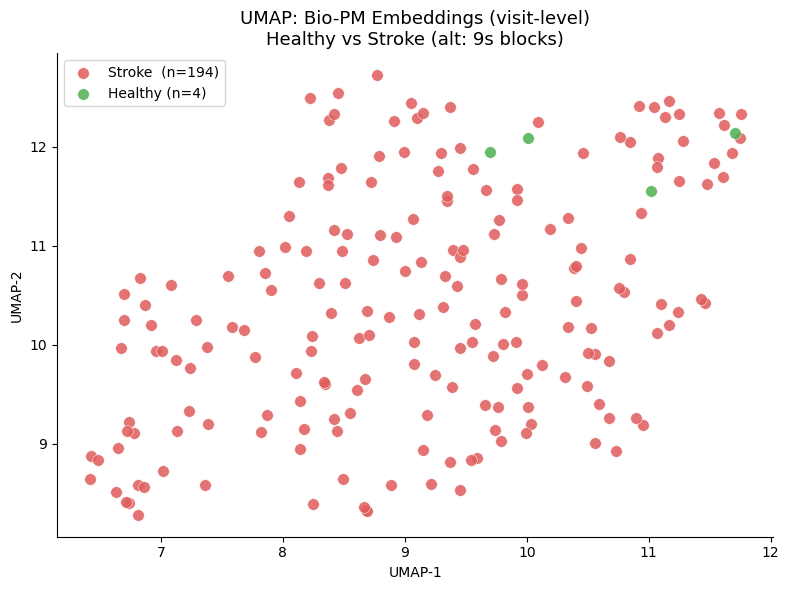


[3/3] LOSO logistic regression ...


LOSO LR:   0%|          | 0/36 [00:00<?, ?subj/s]

LOSO LR Results -- Alt pipeline (9s grouped blocks)
Total visits   : 198
Healthy visits : 4
Stroke visits  : 194

Subjects with mixed labels (AUC computable):
  Subject 532: AUC=0.429  healthy_visits=1
  Subject 533: AUC=0.429  healthy_visits=1
  Subject 539: AUC=0.857  healthy_visits=1
  Subject 551: AUC=0.667  healthy_visits=1

Overall LOSO AUC      : 0.6753
Overall LOSO Macro-F1 : 0.7843

LOSO AUC : 0.6753  PASS
LOSO F1  : 0.7843
Outputs  : results/


In [8]:
print("=" * 56)
print("Bio-PM IRB Analysis (Alt pipeline)")
print("=" * 56)

an_features, an_labels, an_subj, an_week, an_arat, an_fma = load_features(FEATURES_PATH)
N = len(an_labels)
print(f"  Windows : {N}")
print(f"  Healthy : {an_labels.sum()} windows")
print(f"  Stroke  : {(an_labels == 0).sum()} windows")

# 1. Even/odd split
print("\n[1/3] Even/odd block split ...")
train_mask, test_mask = even_odd_split(an_subj, an_week)
os.makedirs(SPLITS_DIR, exist_ok=True)
split_path = os.path.join(SPLITS_DIR, "split_indices_alt.npz")
np.savez(split_path, train_mask=train_mask, test_mask=test_mask)
print(f"  Train blocks  : {train_mask.sum()}")
print(f"  Test  blocks  : {test_mask.sum()}")
print(f"  Train healthy : {an_labels[train_mask].sum()}")
print(f"  Test  healthy : {an_labels[test_mask].sum()}")
print(f"  Saved: {split_path}")

# Visit-level aggregation
print("\nAggregating to visit level ...")
vf, vl, vs, vw, va, vfma = aggregate_visits(
    an_features, an_labels, an_subj, an_week, an_arat, an_fma
)
print(f"  Total visits   : {len(vl)}")
print(f"  Healthy visits : {int(vl.sum())}")
print(f"  Stroke  visits : {int((vl == 0).sum())}")

# 2. UMAP
print("\n[2/3] UMAP visualization ...")
umap_path = os.path.join(FIGURES_DIR, "umap_healthy_vs_impaired_alt.png")
emb = run_umap(vf, vl, umap_path, title_suffix=" (alt: 9s blocks)")

# 3. LOSO LR
print("\n[3/3] LOSO logistic regression ...")
overall_auc, overall_f1, _ = loso_lr(vf, vl, vs, LR_RESULTS_PATH)

print("\n" + "=" * 56)
print(f"LOSO AUC : {overall_auc:.4f}  {'PASS' if overall_auc > 0.6 else 'FAIL -- investigate'}")
print(f"LOSO F1  : {overall_f1:.4f}")
print(f"Outputs  : {RESULTS_DIR}/")
print("=" * 56)

## 5. Legacy Schema + Standard vs Alt Comparison

Load the legacy-compatible visit schema and compare alt results against the standard pipeline.
Both `features` and `features_even/odd` are 1028-d Bio-PM embeddings in both files.
The only difference is embedding quality (fill rate improvement).

In [9]:
if not os.path.isfile(LEGACY_FEATURES_PATH):
    raise FileNotFoundError(
        f"{LEGACY_FEATURES_PATH} not found.\n"
        "Run: bash run_extraction_pipeline_alt.sh (step 4 exports legacy schema)."
    )

legacy = np.load(LEGACY_FEATURES_PATH, allow_pickle=True)
Xv    = np.ascontiguousarray(legacy["features"],      dtype=np.float32)
yv    = legacy["labels"].astype(np.int32)
sv    = legacy["subjects"].astype(np.int32)
pids  = legacy["pids"].astype(np.int32)
arat  = legacy["arat"].astype(np.float32)

print("Loaded alt legacy-schema file:", LEGACY_FEATURES_PATH)
print("  features      :", Xv.shape)
print("  features_even :", legacy["features_even"].shape)
print("  features_odd  :", legacy["features_odd"].shape)

# ---- Compare transformer stream quality between standard and alt ----
std_legacy_path = "features/biopm_features_legacy_schema.npz"
if os.path.isfile(std_legacy_path):
    std_legacy = np.load(std_legacy_path, allow_pickle=True)
    Xs = std_legacy["features"]
    
    print("\n" + "=" * 56)
    print("Embedding quality: Standard vs Alt")
    print("=" * 56)
    for name, X in [("Standard (3s, fill ~33%)", Xs), ("Alt (9s, fill ~96%)", Xv)]:
        mean_abs = float(np.abs(X[:, :128]).mean())
        std_pool = float(np.abs(X[:, 64:128]).mean())
        grav     = float(np.abs(X[:, 128:]).mean())
        print(f"  {name}")
        print(f"    Transformer [0:128]  mean_abs = {mean_abs:.4f}")
        print(f"    Std-pool   [64:128]  mean_abs = {std_pool:.4f}  <-- key improvement")
        print(f"    Gravity    [128:]    mean_abs = {grav:.4f}")
        print()
else:
    print("Standard legacy schema not found -- run standard pipeline to compare.")

Loaded alt legacy-schema file: features/biopm_features_legacy_schema_alt.npz
  features      : (198, 1028)
  features_even : (198, 1028)
  features_odd  : (198, 1028)

Embedding quality: Standard vs Alt
  Standard (3s, fill ~33%)
    Transformer [0:128]  mean_abs = 0.5476
    Std-pool   [64:128]  mean_abs = 0.4137  <-- key improvement
    Gravity    [128:]    mean_abs = 0.0020

  Alt (9s, fill ~96%)
    Transformer [0:128]  mean_abs = 0.5581
    Std-pool   [64:128]  mean_abs = 0.4319  <-- key improvement
    Gravity    [128:]    mean_abs = 0.0028

